In [3]:
import numpy as np
import cv2
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


Flatten all files into 1d vectors and put them in variables.

In [4]:
def load_filtered_data(directory, threshold=20):
    images = []
    labels = []
    removed_count = 0

    path_list = list(Path(directory).glob('*.pgm'))

    for img_path in path_list:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        if img is not None:
            # Calculate the average brightness of the image
            if np.mean(img) > threshold:
                images.append(img.flatten())
                labels.append(img_path.name.split('_')[0])
            else:
                # cv2.imshow("Blah", img)
                # cv2.waitKey(0)
                # cv2.destroyAllWindows()
                removed_count += 1

    print(f"Directory: {directory}")
    print(f"Kept: {len(images)} | Removed (too dark): {removed_count}")
    return np.array(images), np.array(labels)

# Example usage:
X_train, y_train = load_filtered_data('Train Set (Split)/train', threshold=20)
X_test, y_test = load_filtered_data('Train Set (Split)/test', threshold=20)

print(f"X_train shape: {X_train.shape}")  # Should be (~14364, 4608)
print(f"X_test shape: {X_test.shape}")    # Should be (~1596, 4608)

Directory: Train Set (Split)/train
Kept: 14044 | Removed (too dark): 335
Directory: Train Set (Split)/test
Kept: 1586 | Removed (too dark): 39
X_train shape: (14044, 4608)
X_test shape: (1586, 4608)


Run PCA to determine maximum variation directions.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(float))
X_test_scaled = scaler.transform(X_test.astype(float))

pca = PCA(n_components=0.95, whiten=True)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features: {X_train.shape[1]}")
print(f"Reduced features: {X_train_pca.shape[1]}")

Original features: 4608
Reduced features: 325


In [6]:
import matplotlib.pyplot as plt

C:\Users\TLP-001\AppData\Local\Temp\ipykernel_42040\1341150316.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


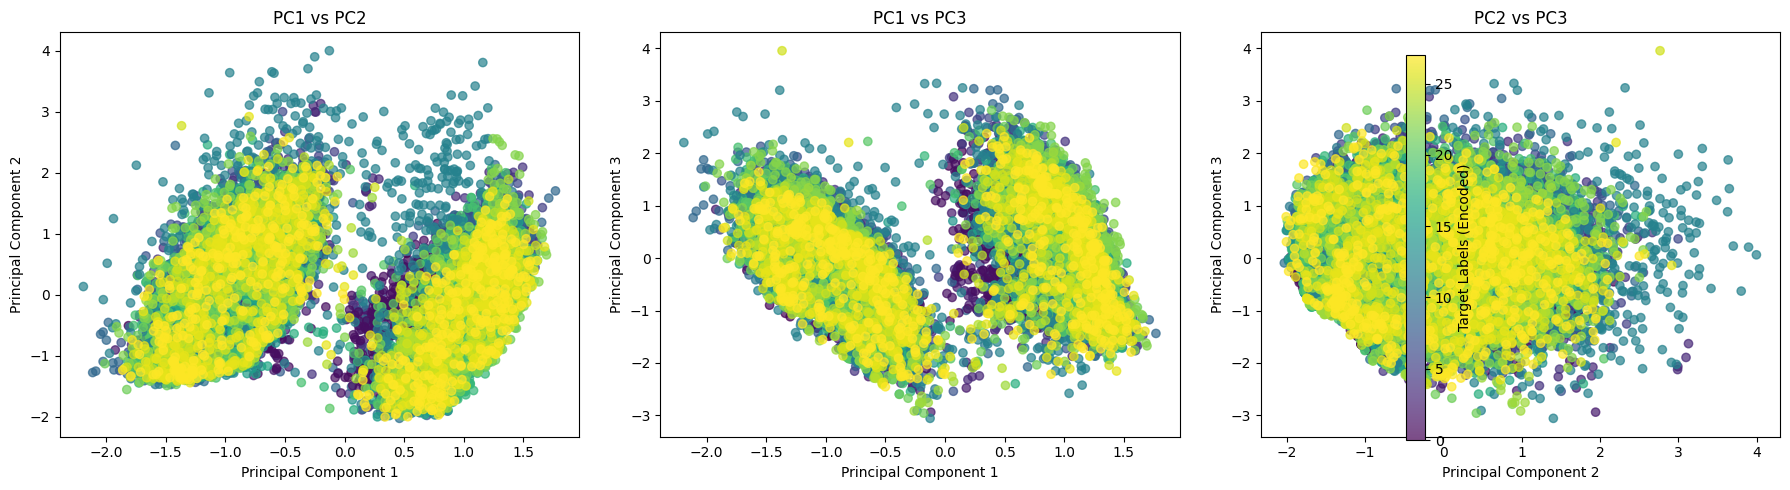

In [9]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 1. Convert string labels ('p0', 'p1'...) to numbers (0, 1...)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# 2. Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: PC1 vs PC2
scatter1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_encoded, cmap='viridis', alpha=0.7)
axes[0].set_title('PC1 vs PC2')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Graph 2: PC1 vs PC3
scatter2 = axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 2], c=y_train_encoded, cmap='viridis', alpha=0.7)
axes[1].set_title('PC1 vs PC3')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 3')

# Graph 3: PC2 vs PC3
scatter3 = axes[2].scatter(X_train_pca[:, 1], X_train_pca[:, 2], c=y_train_encoded, cmap='viridis', alpha=0.7)
axes[2].set_title('PC2 vs PC3')
axes[2].set_xlabel('Principal Component 2')
axes[2].set_ylabel('Principal Component 3')

# Add a colorbar
# Note: The colorbar will now show the integer representations (0-9)
fig.colorbar(scatter1, ax=axes.ravel().tolist(), label='Target Labels (Encoded)')

# Adjust layout and show
plt.tight_layout()
plt.show()

Extracting HOG features... (this might take a few seconds)
Final training data shape: (14044, 100)


C:\Users\TLP-001\AppData\Local\Temp\ipykernel_42040\967983106.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


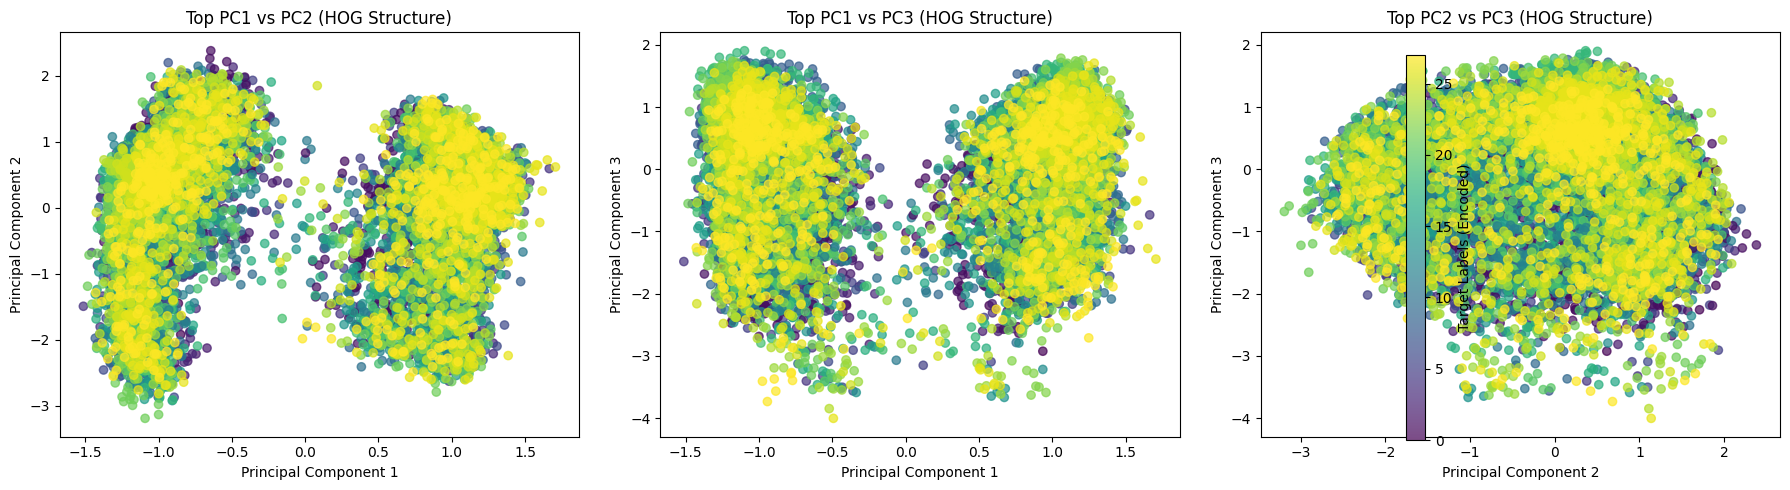

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# --- 0. ENCODE LABELS FOR PLOTTING ---
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# --- 1. RESHAPE RAW DATA FOR HOG ---
X_train_images = X_train.reshape(-1, 64, 72)
X_test_images = X_test.reshape(-1, 64, 72)

# --- 2. EXTRACT HOG FEATURES ---
def get_hog_features(images):
    features_list = []
    for img in images:
        fd = hog(img, orientations=9, pixels_per_cell=(8, 8),
                 cells_per_block=(2, 2), visualize=False)
        features_list.append(fd)
    return np.array(features_list)

print("Extracting HOG features... (this might take a few seconds)")
X_train_hog = get_hog_features(X_train_images)
X_test_hog = get_hog_features(X_test_images)

# --- 3. SCALE BOTH DATASETS INDEPENDENTLY ---
scaler_raw = StandardScaler()
X_train_raw_scaled = scaler_raw.fit_transform(X_train)
X_test_raw_scaled = scaler_raw.transform(X_test)

scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog)
X_test_hog_scaled = scaler_hog.transform(X_test_hog)

# --- 4. APPLY PCA TO COMPRESS BOTH ---
pca_hog = PCA(n_components=50, whiten=True)
X_train_hog_pca = pca_hog.fit_transform(X_train_hog_scaled)
X_test_hog_pca = pca_hog.transform(X_test_hog_scaled)

pca_raw = PCA(n_components=50, whiten=True)
X_train_raw_pca = pca_raw.fit_transform(X_train_raw_scaled)
X_test_raw_pca = pca_raw.transform(X_test_raw_scaled)

# --- 5. CONCATENATE (GLUE) THEM TOGETHER ---
X_train_final = np.hstack((X_train_hog_pca, X_train_raw_pca))
X_test_final = np.hstack((X_test_hog_pca, X_test_raw_pca))

print(f"Final training data shape: {X_train_final.shape}")

# --- 6. PLOT THE FIRST 3 COMPONENTS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: PC1 vs PC2
scatter1 = axes[0].scatter(X_train_final[:, 0], X_train_final[:, 1], c=y_train_encoded, cmap='viridis', alpha=0.7)
axes[0].set_title('Top PC1 vs PC2 (HOG Structure)')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Graph 2: PC1 vs PC3
scatter2 = axes[1].scatter(X_train_final[:, 0], X_train_final[:, 2], c=y_train_encoded, cmap='viridis', alpha=0.7)
axes[1].set_title('Top PC1 vs PC3 (HOG Structure)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 3')

# Graph 3: PC2 vs PC3
scatter3 = axes[2].scatter(X_train_final[:, 1], X_train_final[:, 2], c=y_train_encoded, cmap='viridis', alpha=0.7)
axes[2].set_title('Top PC2 vs PC3 (HOG Structure)')
axes[2].set_xlabel('Principal Component 2')
axes[2].set_ylabel('Principal Component 3')

# Add colorbar
fig.colorbar(scatter1, ax=axes.ravel().tolist(), label='Target Labels (Encoded)')

plt.tight_layout()
plt.show()

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# --- 1. ENCODE THE TEST LABELS ---
# We use the exact same LabelEncoder ('le') we fitted on the training data 
# so that the numbers match perfectly (e.g., 'p0' always = 0)
y_test_encoded = le.transform(y_test)

# --- 2. INITIALIZE THE SVM ---
# kernel='rbf': Allows the model to draw curved, non-linear boundaries.
# class_weight='balanced': Helps if some people have fewer photos than others.
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# --- 3. TRAIN THE MODEL ---
print("Training the SVM model on combined HOG + PCA features...")
svm_model.fit(X_train_final, y_train_encoded)

# --- 4. MAKE PREDICTIONS ---
print("Making predictions on the unseen test set...")
predictions = svm_model.predict(X_test_final)

# --- 5. PRINT PERCENTAGE OF SUCCESS ---
accuracy = accuracy_score(y_test_encoded, predictions)
success_percentage = accuracy * 100

print("\n======================================")
print(f"🎉 Percentage of Success: {success_percentage:.2f}%")
print("======================================\n")

# --- 6. (OPTIONAL) DETAILED BREAKDOWN ---
# This shows exactly which people (classes) the model struggled with
print("Detailed Classification Report (per person):")
print(classification_report(y_test_encoded, predictions, target_names=le.classes_))

Training the SVM model on combined HOG + PCA features...
Making predictions on the unseen test set...

🎉 Percentage of Success: 95.96%

Detailed Classification Report (per person):
              precision    recall  f1-score   support

          p0       1.00      1.00      1.00        56
          p1       0.98      0.97      0.97        58
         p10       1.00      0.98      0.99        58
         p11       0.96      0.95      0.96        58
         p12       0.98      0.97      0.97        58
         p13       0.91      0.95      0.93        56
         p14       0.98      0.93      0.95        56
         p15       1.00      1.00      1.00        58
         p16       1.00      1.00      1.00        56
         p17       0.95      0.91      0.93        58
         p18       0.90      0.96      0.93        56
         p19       0.98      0.91      0.95        58
          p2       0.84      1.00      0.91        58
         p20       0.98      0.92      0.95        53
        